# Olist E-Commerce — Customer Review Sentiment Analysis
**Author:** Maeen Mohammed  
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Objective:** Translate Portuguese customer reviews to English, classify themes, and apply sentiment analysis using VADER.

---
## Pipeline Overview
1. Load & explore raw review data
2. Assign sentiment labels based on review score
3. Translate Portuguese reviews to English
4. Classify review themes using keyword matching
5. Apply VADER sentiment analysis
6. Merge with order/customer/geolocation data
7. Export final dataset for Power BI

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Raw Data

In [2]:
# Update this path to your local dataset location
DATA_PATH = 'data/'

# Load datasets
reviews_df = pd.read_csv('../data/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('../data/olist_orders_dataset.csv')
order_items_df = pd.read_csv('../data/olist_order_items_dataset.csv')
customers_df = pd.read_csv( '../data/olist_customers_dataset.csv')
products_df = pd.read_csv('../data/olist_products_dataset.csv')
geolocation_df = pd.read_csv('../data/olist_geolocation_dataset.csv')

print('Shape of reviews dataset:', reviews_df.shape)
reviews_df.head(3)

Shape of reviews dataset: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,18/01/2018 0:00,18/01/2018 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,10/03/2018 0:00,11/03/2018 3:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,17/02/2018 0:00,18/02/2018 14:36


## 3. Explore & Clean Reviews

In [3]:
# Basic info
print(reviews_df.info())
print('\nMissing values:')
print(reviews_df.isnull().sum())
print('\nScore distribution:')
print(reviews_df['review_score'].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None

Missing values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [4]:
# Keep only reviews with comment messages
review_clean = reviews_df[reviews_df['review_comment_message'].notna()].copy()
review_clean = review_clean.drop_duplicates(subset='review_id')
review_clean = review_clean.drop(columns=['review_comment_title', 'review_answer_timestamp'])

# Convert date column
review_clean['review_creation_date'] = pd.to_datetime(
    review_clean['review_creation_date'], dayfirst=True
)

print('Reviews with comments:', len(review_clean))
review_clean.head(3)

Reviews with comments: 40668


,review_id,order_id,review_score,review_comment_message,review_creation_date
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,2017-04-21
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Pá...,2018-03-01
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta...,2018-05-22


## 4. Assign Sentiment Label Based on Review Score

In [5]:
def assign_sentiment_label(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

review_clean['sentiment_label'] = review_clean['review_score'].apply(assign_sentiment_label)

print('Sentiment label distribution:')
print(review_clean['sentiment_label'].value_counts())

Sentiment label distribution:
sentiment_label
Positive    26380
Negative    10759
Neutral      3529
Name: count, dtype: int64


## 5. Translate Reviews from Portuguese to English
> **Note:** This step takes approximately 90 minutes for ~9,800 rows due to API rate limits.  
> The translated output is saved to CSV so this step only needs to run once.

In [ ]:
def translate_text(text):
    """Translate a single text from Portuguese to English."""
    try:
        if pd.isna(text) or str(text).strip() == '':
            return text
        time.sleep(0.1)  # Avoid rate limiting
        return GoogleTranslator(source='pt', target='en').translate(str(text)[:4999])
    except Exception:
        return text  # Return original if translation fails

# Translate with progress tracking
translated = []
total = len(review_clean['review_comment_message'])

for i, text in enumerate(review_clean['review_comment_message']):
    translated.append(translate_text(text))
    if i % 500 == 0:
        print(f'Progress: {i}/{total}')

review_clean['review_comment_message_en'] = translated

# Save translated reviews immediately
review_clean.to_csv('data/reviews_translated.csv', index=False)
print('Translation complete and saved.')

In [10]:
# Load translated reviews (skip translation step on re-run)
translate_reviews = pd.read_csv('../data/reviews_translated.csv')
print('Translated reviews loaded:', translate_reviews.shape)
print('Empty translations:', translate_reviews['review_comment_message_en'].isna().sum())

Translated reviews loaded: (9808, 11)
Empty translations: 0


## 6. Theme Classification
Keyword-based classification covering 12 themes with 99.7% coverage.

In [11]:
theme_keywords = {
    'Delivery & Shipping': [
        'delivery', 'delivered', 'shipping', 'arrived', 'deadline',
        'fast', 'quick', 'late', 'delayed', 'on time', 'early', 'before',
        'didn\'t deliver', 'not deliver', 'haven\'t received', 'not received yet',
        'waiting', 'correios', 'tracking', 'distribution', 'send it',
        'bought in one day', 'received the next day', 'didn\'t arrive',
        'delay', 'more than a month', 'no update', 'days to arrive', 'punctual',
        'took a long time', 'long time to deliver', 'coming from china',
        'still in the hands', 'courier', 'will the product still arrive',
        'when will i receive', 'sent to the south', 'track the order',
        'can\'t track', 'still on schedule', 'too long', 'strike',
        'truck drivers', 'received the product days after',
        'slow to arrive', 'simply didn\'t deliver',
        'where is it', 'i want my product', 'i need to receive',
        'more dedication in the next deliveries', 'hope for more dedication',
        'more than 30 days', 'just doesn\'t deliver', 'it just doesn\'t deliver',
        'transport company informed', 'was away from home',
        'i don\'t have the product in hand', 'carrier',
        'scheduled date', 'frustrated when it didn\'t happen',
        'dynamic logistics', 'fulfills its responsibilities',
        'took a while', 'i thought it took a while',
        'did not receive my products in a timely manner',
        'long overdue', 'did not have approval', 'pick up the product',
        'i had to pick up', 'i\'m grateful for the speed',
        'shptime always', 'always 100%',
        'took so long to receive', 'i would like to know why',
        'i had to go look for it', 'received it ahead of schedule',
        'i\'m in need of my product', 'a month to arrive',
        'never taken so long', 'it\'s never taken so long',
        'takes time to deliver', 'received it in two shipments',
        'agility makes a difference', 'meeting dates',
        'p0ntualidade', 'punctualidade'
    ],
    'Product Quality': [
        'quality', 'perfect', 'defective', 'broken', 'original',
        'falsified', 'exceeded', 'expectations', 'fragrant', 'beautiful',
        'condition', 'works', 'working', 'damaged', 'thin', 'balls',
        'filament', 'heats', 'fits', 'ideal', 'worth buying', 'effective',
        'practical', 'objective', 'fragile', 'reinforced', 'could be better',
        'more explicit', 'shallow', 'badly placed', 'bubble', 'not close',
        'not sharpened', 'shed hair', 'come apart', 'easy to assemble',
        'very bad', 'worn', 'does not close', 'came apart', 'resistant',
        'filling', 'loose', 'screw', 'hurting', 'narrow', 'no aroma',
        'lasting power', 'counterfeit', 'piracy', 'fake', 'unsealed',
        'empty', 'without ink', 'voltage', 'cute', 'comfortable',
        'strange smell', 'functionality', 'as described', 'parallel',
        'replica', 'japanese technology', 'too tight', 'doesn\'t work',
        'intercom', 'painting', 'larger than', 'pretty box', 'hooks',
        'thick cover', 'easy to fold', 'good material', 'as seen in the photos',
        'cloying', 'sweet', 'fragrances', 'expire', 'dark stains',
        'lack of care', 'did not work', 'worked', 'cool product',
        'just like the photo', 'good finish', 'compatible',
        'doesn\'t fit', 'not fit', 'cooker', 'specifications', 'crooked',
        'complies with', 'configuration', 'should test', 'simple but useful',
        'out of specification', 'came bad', 'very sharp', 'cut well',
        'reduce the brightness', 'very inferior', 'inferior',
        'instructions on how to use', 'helps me a lot',
        'buttons are weak', 'disassembled', 'difficult to assemble',
        'synthetic leather', 'doesn\'t hurt', 'easy to use',
        'batteries that last', 'beyond compare', 'didn\'t work for the car',
        'size specified', 'composition does not correspond',
        'usable', 'not what you expect', 'case is not chrome',
        'glass is acrylic', 'poorly welded', 'patched', 'detail-oriented',
        'small stain', 'golden part', 'camera didn\'t work',
        'control functions', 'basic functions',
        'base is small', 'doesn\'t fit the labrador', 'image is very deceiving',
        'came in dark color', 'much smaller than expected', 'too big for me',
        'very pretty', 'stands out well', 'wallet model was great',
        'mirror fogs up', 'anti-fog', 'fogs up less', 'very little water',
        'old tap back', 'tarpaulin', 'prevent light', 'well built',
        'delivers as promised', 'surprising', 'should be a little bigger',
        'no effect whatsoever', 'can\'t make contact', 'more testing',
        'apparently it didn\'t work', 'birds responded very well',
        'many burrs', 'risk of cuts', 'propeller', 'it\'s small',
        'velcro closure', 'super suitable', 'difficulty recognizing',
        'back to normal', 'makes it a lot easier', 'damaging their hair',
        'cracks in the front acrylic', 'not what i thought it would be',
        'bible a little expensive', 'easy and simple', 'blackout curtain',
        'functions are for illustrative', 'do not only work all the time',
        'muscle pain', 'not been successful', 'very useful product',
        'very light compared', 'completely made of plastic',
        'more powerful', 'router does what it promises', 'goes through walls',
        'great tool for home work', 'very useful',
        'activates more than one button', 'volume and on/off buttons',
        'factory defect', 'needs to improve a lot', 'received an old product',
        'lack of substantial information', 'digital watch without light',
        'leaves a lot to be desired', 'very weak product', 'weak product',
        'order a little more', 'doesn\'t have the size stated',
        'burned out leds', 'found it weak', 'old product',
        'appears to have been recovered', 'knife does what it promises',
        'very efficient', 'very cool', 'very nice backpack',
        'imagined it would be smaller', 'will never recover my files',
        'no instruction manual', 'looks burnt', 'got hot and didn\'t work',
        'plugged in it got hot', 'it\'s not a mirror', 'product does not work',
        'well finished product', 'manufacturing date over a year',
        'expiration date in four months', 'generic product',
        'could improve', 'minimum quantity', 'moisturizes well',
        'doesn\'t straighten', 'material lower than expected',
        'product too small', 'used device', 'helps a lot in my daily life'
    ],
    'Wrong Item Received': [
        'wrong', 'different', 'another color', 'not the product',
        'sent was not', 'wrong product', 'wrong size', 'wrong color',
        'received marmitas', 'bought a set', 'cans and received',
        'not as advertised', 'not what i bought', 'advertises a kit',
        'bought iso', 'received nitro', 'this one came out correct. the first',
        'cable extensions', 'film that came with it', 'not for the',
        'not the voltage', 'received two', 'received one completely',
        'sent me two curtains', 'bought a product for',
        'bucket bag came from', 'bought the product in orange', 'came in yellow',
        'bought a 250m', 'received a 100m', 'description does not match',
        'model received', 'received the samsumg', 'frontier', 'ford ranger',
        'gel in the advertisement', 'common plastic film', 'film that they say',
        'impression that it is two items', 'in fact it is just one',
        'image released gives', 'product i received was incorrect',
        'does not correspond to what is advertised',
        'did not come as we expected',
        'bought a watch and they sent me another', 'smaller size',
        'not approach the actual size', 'bought a sony', 'received a kdl',
        'wanted a dvd player and not a recorder',
        'invoice describes the correct', 'product received is another',
        'bought an hp deskjet', 'received a 1115', 'official size',
        'not the color of the advertisement', 'he is pink',
        'cover for a 14', 'received a cover for a larger',
        'product in the photo is not the same', 'false advertising',
        'does not match the description', 'name of the product states',
        'it is not the color', 'came in the box of another product',
        'headlight was like black', 'came in chrome',
        'i ordered one product and received another',
        'i thought it was one product but it\'s another',
        'targaryen sent another product', 'they sent another product',
        'note came with the name of another company',
        'ivory basket and received a green', 'ordered in pearl color and came white',
        'requested the white and lilac', 'receive an invoice with the white and purple',
        'my choice was worthless', 'lids were black',
        'product was not the same as the photo',
        'i bought a product and received another',
        'but i thought the lids', 'changed my product',
        'sent me someone else\'s product',
        'beer tower that was sent to me in error',
        'dissatisfaction with the purchase of a beer tower',
        'cup is not exactly as it is in the photo',
        'lid is black and contrary', 'lid is white',
        'i made a purchase of a product and received another product',
        'bought liquid and it came with pills',
        'black background came with white background',
        'pedi casio silver with black background',
        'deceived by a product similar', 'similar product',
        'surprised when i received', 'cachepot received buxinho',
        'purchased cachepot', 'measurements large bag',
        'reality consumer', 'cm high x', 'cm wide x'
    ],
    'Packaging': [
        'packaging', 'packed', 'separate box', 'wasteful',
        'wrapped', 'package'
    ],
    'Customer Service': [
        'seller', 'service', 'attended', 'response', 'support',
        'respect', 'rude', 'helpful', 'trustworthy',
        'website', 'seriousness', 'efficiency', 'serious',
        'very attentive', 'attentive', 'sac', 'poorly organized',
        'no one sent', 'no explanation', 'never lets me down',
        'long time customer', 'loyal customers',
        'very correct with its buyers', 'rating 10 for',
        'do not respond to requests', 'great with tinua',
        '100% store', 'customers for a long time',
        'trusted store', 'store\'s reputation',
        'total professionalism', 'no option to call to complain',
        'contacted targaryen', 'don\'t sell hygiene kits',
        'can\'t contact you', 'first time i have problems',
        'great way of sales', 'confidence this store provides',
        'difficult to contact', 'manufacturer store helped',
        'reasonable store', 'american store',
        'to this day i have received what the store promised',
        'i only buy from this site', 'have security',
        'lannister is great', 'fulfilled their promise',
        'customer satisfaction', 'two purchases from targaryen',
        'haven\'t had any problems', 'i can never talk to lannister',
        'my favorite store', 'can never talk to lannister stores',
        'i really like this store', 'buy it often', 'total confidence',
        'i\'ve been buying for several years', 'no complaints',
        'i have no complaints', 'i was very well taken care of'
    ],
    'Missing Item': [
        'missing', 'only received', 'incomplete', 'not received',
        'one instead', 'didn\'t receive', 'not arrive', 'still waiting',
        'waiting for', 'haven\'t received', 'i haven\'t received',
        'did not come', 'only gave me', 'only send one', 'not come full',
        'need the medicine', 'came without', 'without a pacifier',
        'lamp did not', 'only sent me 1', 'sent me 1 light',
        'did not receive the cartridges', 'however i did not receive',
        'invoice saying i had two', 'received one and the invoice',
        'ordered three numbers', 'only the 0/7 came',
        'canceled as requested', 'i didn\'t order it',
        'only sent one unit', 'purchased three units',
        'issued a receipt for all three',
        'only one of the items was sent', 'was not shipped', 'no product',
        'this time i did not receive', 'did not receive the product i purchased',
        'i did not receive the product', 'no invoice came',
        'enter only one unit', 'pay for two units', 'invoice shows two units',
        'ordered 2 units, received 1', 'nf said 2 units',
        'only given 1 rca cable', 'bought 3 rca cables',
        'only sent me one product out of two',
        'two purchased in the same order',
        'received the mask with cracks',
        'not even the note was issued', 'during the entire period',
        'bought two lamps and only one came',
        'purchased two blankets but ended up receiving only one',
        'i ordered 2 items and only one was sent',
        'bought 3 bottles of wine, only two came',
        'you pay and don\'t receive',
        'cannot evaluate a product that i did not receive',
        'bought two dolls lol only one came', 'only one watch came',
        'i hope you will resend me', 'i partially received it',
        'no communication was given', 'partial'
    ],
    'Payment & Refund': [
        'refund', 'charge', 'card', 'installment', 'money', 'paid',
        'payment', 'resolve', 'refund request', 'not available',
        'canceled the order', 'no merchandise in stock',
        'not for sale', 'after 3 weeks', 'contact procon',
        'price that wasn\'t good', '300% cheaper',
        'presented a product that they did not have in stock',
        'request cancellation', 'i request cancellation',
        'need to be reimbursed', 'reimbursed the amount',
        'should be cheaper', 'could you give me a discount',
        'went to 1,690'
    ],
    'Returns & Exchange': [
        'exchange', 'return', 'didn\'t do it', 'asked for an exchange',
        'want to return', 'send back', 'i want to cancel this purchase',
        'cancel this purchase', 'i want to make the change',
        'taking a long time', 'i really need you to send me back my order'
    ],
    'General Positive': [
        'recommend', 'excellent', 'satisfied', 'love', 'great product',
        'happy', 'amazing', 'wonderful', 'liked',
        'congratulations', 'guaranteed', 'keep it up',
        'thank', 'everything i expected', 'as per', 'as ordered',
        'as expected', 'as advertised', 'as purchased', 'correctly',
        'received the product correctly', 'received the order correctly',
        'product as ordered', 'product as expected', 'came as ordered',
        'very good', 'all very well', 'always good', 'good buy',
        'no problems', 'correct product', 'the product is good',
        'but it\'s good', 'worth it', 'great prices',
        'good product', 'product as requested', 'never had any problems',
        'really good', 'note 10', 'good pillows', 'great store',
        'best store', 'great joystick', 'all the best', 'good functionality',
        'good purchase', 'was a good purchase', 'looks good',
        'very comfortable', 'very cute', 'better than i expected',
        'exactly what i was looking for', 'met my needs', 'great purchase',
        'my purchase was great', 'good to shop', 'will buy again',
        'i buy and will always buy', 'no problem', 'i will buy again',
        'best online stores', 'had a lot of pleasure',
        'experience without any negative', 'great to have purchased',
        'always bought from', 'never had a problem',
        'stores are the best', 'all right', 'top', 'already using it',
        'much earlier than expected', 'great to make the purchase',
        'always buy very reliable', 'ball show', 'top d+',
        'impossible better', 'fantastic', 'corn show', 'will continue buying',
        'rating 10', 'got a free book', 'meets the request',
        'perfume is great', 'buy without fear', '5 stars',
        'really like it', 'pump is great', 'eubrecomando',
        'i would buy again', 'reliable', 'satisfactory purchase',
        'really enjoyed buying', 'enhances the shopping experience',
        'approved', 'no stress', 'best shopping site',
        'lannister note ten', 'satisfactory doll', 'i will always buy',
        'that\'s what i expected', 'simply great', 'lannister note 1000',
        'just thought this wallet model was great', 'i always buy them',
        'i like the lannisters', 'just the way i wanted',
        'great as always', 'well built and delivers as promised',
        'will make other requests', 'received in the contracted form',
        'all is well', 'one hundred percent', 'pleasure to shop',
        'it was as i expected', 'success to you', 'already knew the product',
        'the product was exactly what i needed',
        'product is exactly as i imagined', 'it\'s always a pleasure',
        'legal', 'i always buy from lannister', 'commendable',
        'product exactly as requested', 'you are 1000',
        'i enjoyed shopping with you', 'always purchased from lannister',
        'i really like the american store', 'great', 'show',
        'great and safe purchase', 'i\'m grateful',
        'fulfilled their promise', 'customer satisfaction',
        'i really like buying', 'boom', 'i\'ll buy more',
        'i\'ve already made two purchases', 'interesting purchasing system',
        'proven competence', 'professionalism',
        'will definitely buy other products',
        'lannister i always bought', 'every day better',
        'super reconendo', 'lannister is 10',
        'product came what i really expected',
        'i positively acknowledge receipt', 'powder buy',
        'cool', 'came as i expected', 'correct', 'product ok',
        'i am very pleased to buy', 'ok received', 'as agreed',
        'so right', 'best price', 'met my need', 'sensational',
        'bought and received', 'sensational product', 'satisfactory',
        'we all agree', 'product meets needs', 'nice',
        'will make new purchases', 'exactly what i bought',
        'as requested', 'satisfaction', 'according to information',
        'i have no complaints', 'i was very well taken care of',
        'total confidence', 'i\'ve been buying for several years',
        'fulfilled what was promised', 'that\'s what i needed',
        'success', 'best company', 'product according to price',
        'my favorite sait', 'it helps a lot', 'as collected'
    ],
    'General Negative': [
        'terrible', 'worst', 'disappointed', 'horrible',
        'awful', 'useless', 'waste', 'never again', 'spent a lot',
        'too thin', 'a shame', 'unfortunately', 'did not send',
        'not send the product as advertised', 'rubbish', 'don\'t buy',
        'total repentance', 'can\'t get it to work', 'bad purchase',
        'absurd', 'clown', 'will never buy', 'lost a customer',
        'never buy from this company', 'hated it', 'through court',
        'bad faith', 'no more', 'very inferior', 'shouldn\'t have bought',
        'can\'t talk to you', 'bad', 'i expected more',
        'too much', 'i didn\'t like it', 'ruin',
        'would not have made the purchase', 'embarrassed by the situation',
        'fuck', 'upset because it was 2000', 'i\'m sorry',
        'negative situations', 'dissatisfaction',
        'leaves a lot to be desired', 'very weak product',
        'negative', 'i will never recover my files', 'huge problem',
        'deleted music', 'deleted photos', 'regretted it bitterly',
        'a shit', 'frustration', 'deceived by a product',
        'didn\'t pay attention when buying', 'material lower than expected'
    ],
    'No Comment': [
        'okay', 'no comments', 'haven\'t used',
        'not used yet', 'patience', 'obliging',
        'no information', 'it\'s in the testing', 'okkkk', 'ezcrlente',
        'i don\'t even know what to say', 'i\'ll see if',
        'need to use', 'nakjsk', 'and nice', 'semdetahes',
        'i\'m testing', 'i haven\'t tested', 'first purchase',
        'hope i have better luck', 'good', 'continuous improvement',
        'still trying', 'i haven\'t installed', 'i apologize for the previous',
        'it\'s been 9 days', 'question', 'more or less',
        'i didn\'t even see his color', 'okokokokok',
        'i don\'t know why', 'i wait', 'blza', 'wol',
        'he meets', 'eighth term', 'i can\'t wait',
        'product sent is spoken', 'watch has a subject on the inside',
        'normal blackout curtain', 'i would have to have the right size',
        'as soon as i receive', 'the', 'yes', 'normal',
        'device still in testing phase', 'ok ok', 'well...nice straws',
        'how to solve', 'i can\'t rate it yet', 'reasonable product',
        'cool reasonable', 'okok', 'td right', 'bao',
        'entrega super rapida', 'i started using it now', 'ldockcifjfjrh',
        'otima relacao custo beneficio', 'entrega super rapida otimo produto',
        'enselente', 'i can\'t give an evaluation yet',
        'speechless', 'i have no opinion', 'positivity',
        'it cost', 'no criticism', 'i don\'t have', 'ok.'
    ]
}


def classify_theme(text):
    """Classify a review into one of 12 themes using keyword matching."""
    if pd.isna(text) or str(text).strip() == '':
        return 'No Comment'
    if len(str(text).strip()) <= 2:
        return 'No Comment'
    vowels = set('aeiou')
    words = str(text).lower().split()
    if len(words) <= 2 and not any(v in str(text).lower() for v in vowels):
        return 'No Comment'
    text_lower = str(text).lower()
    for theme, keywords in theme_keywords.items():
        if any(keyword in text_lower for keyword in keywords):
            return theme
    return 'Other'


translate_reviews['theme'] = translate_reviews['review_comment_message_en'].apply(classify_theme)

print('Theme distribution:')
print(translate_reviews['theme'].value_counts())

Theme distribution:
theme
Delivery & Shipping    4805
General Positive       1818
Product Quality        1659
No Comment              450
Customer Service        311
Missing Item            278
Wrong Item Received     196
Payment & Refund        110
Returns & Exchange       58
Packaging                50
General Negative         40
Other                    33
Name: count, dtype: int64


## 7. VADER Sentiment Analysis

In [12]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Return VADER sentiment label and compound score."""
    if pd.isna(text) or str(text).strip() == '':
        return 'Neutral', 0.0
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return label, round(compound, 4)

translate_reviews[['vader_sentiment', 'vader_score']] = translate_reviews['review_comment_message_en'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print('VADER sentiment distribution:')
print(translate_reviews['vader_sentiment'].value_counts())
print('\nAverage VADER score by theme:')
print(translate_reviews.groupby('theme')['vader_score'].mean().sort_values())

VADER sentiment distribution:
vader_sentiment
Positive    6243
Neutral     2193
Negative    1372
Name: count, dtype: int64

Average VADER score by theme:
theme
General Negative      -0.410605
Wrong Item Received   -0.134843
Missing Item          -0.034512
Returns & Exchange     0.003040
Payment & Refund       0.099861
No Comment             0.148810
Other                  0.195615
Packaging              0.211808
Product Quality        0.290897
Delivery & Shipping    0.309543
Customer Service       0.354003
General Positive       0.501704
Name: vader_score, dtype: float64


## 8. Sentiment Alignment
Compare original sentiment label (based on star rating) vs VADER sentiment.

In [13]:
translate_reviews['sentiment_alignment'] = translate_reviews.apply(
    lambda row: 'Match' if row['sentiment_label'] == row['vader_sentiment'] else 'Mismatch',
    axis=1
)

print('Sentiment alignment:')
print(translate_reviews['sentiment_alignment'].value_counts())
print('\nCross-tabulation:')
print(pd.crosstab(translate_reviews['sentiment_label'], translate_reviews['vader_sentiment'], margins=True))

Sentiment alignment:
sentiment_alignment
Match       6658
Mismatch    3150
Name: count, dtype: int64

Cross-tabulation:
vader_sentiment  Negative  Neutral  Positive   All
sentiment_label                                   
Negative              960      843       443  2246
Neutral               200      217       319   736
Positive              212     1133      5481  6826
All                  1372     2193      6243  9808


## 9. Merge with Order, Customer & Geolocation Data

In [14]:
# Merge reviews with orders
order_items_clean = order_items_df.groupby('order_id').first().reset_index()[
    ['order_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
]
order_items_clean['total_revenue'] = order_items_clean['price'] + order_items_clean['freight_value']

# Merge with customers
customer_clean = customers_df[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix']].copy()

# Build master dataset
master = translate_reviews.merge(order_items_clean, on='order_id', how='left')
master = master.merge(customer_clean, on='order_id', how='left') if 'customer_id' in master.columns else master

print('Master dataset shape:', master.shape)
master.head(3)

Master dataset shape: (9808, 21)


,Unnamed: 0,index,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,sentiment_label,review_comment_message_en,theme,vader_sentiment,vader_score,sentiment_alignment,product_id,seller_id,shipping_limit_date,price,freight_value,total_revenue
0,0,9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta...,22/05/2018 0:00,23/05/2018 16:45,Positive,efficient device. On the website the brand of the device is printed as 3disinfector and when it ...,Wrong Item Received,Positive,0.4215,Match,61a4100ccd6d9c4c808a1fd954ddb8ad,05ff92fedb5be47920fea08e501238b9,2018-05-17 10:31:31,586.56,26.69,613.25
1,1,15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes do prazo.",23/05/2018 0:00,24/05/2018 3:00,Positive,"Reliable seller, ok product and delivery on time.",Delivery & Shipping,Positive,0.2960,Match,6871a3c157d6f51697e887f3c3598479,974cf2cb8f4b7add98709c30df02fe10,2018-05-24 18:31:29,89.99,13.07,103.06
2,2,19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,15/08/2018 0:00,15/08/2018 4:10,Negative,Terrible,General Negative,Negative,-0.4767,Match,55a1e3d39ace9c0b217f6c30b04d43c0,0be8ff43f22e456b4e0371b2245e4d01,2018-08-08 19:24:33,89.90,9.38,99.28


## 10. Word Cloud Visualization

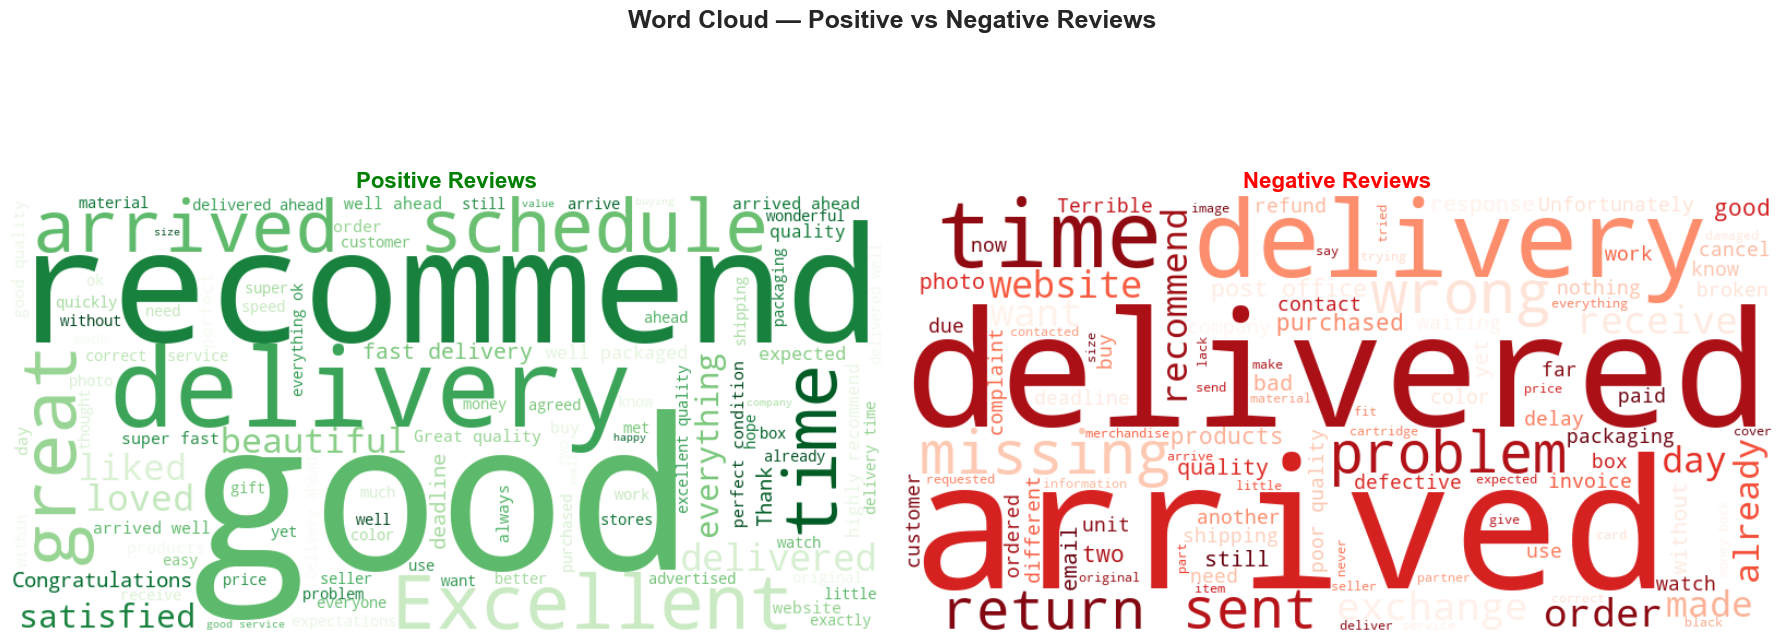

Word cloud saved.


In [16]:
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'product', 'store', 'lannister', 'targaryen', 'baratheon',
    'purchase', 'bought', 'received', 'will', 'just', 'really',
    'also', 'even', 'one', 'get', 'got', 'came', 'come'
])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Positive word cloud
positive_text = ' '.join(
    translate_reviews[translate_reviews['vader_sentiment'] == 'Positive']['review_comment_message_en'].dropna()
)
wordcloud_pos = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Greens', stopwords=custom_stopwords, max_words=100
).generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews', fontsize=16, fontweight='bold', color='green')

# Negative word cloud
negative_text = ' '.join(
    translate_reviews[translate_reviews['vader_sentiment'] == 'Negative']['review_comment_message_en'].dropna()
)
wordcloud_neg = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Reds', stopwords=custom_stopwords, max_words=100
).generate(negative_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews', fontsize=16, fontweight='bold', color='red')

plt.suptitle('Word Cloud — Positive vs Negative Reviews', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs//wordcloud_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()
print('Word cloud saved.')

## 11. Export Final Dataset for Power BI

In [18]:
translate_reviews.to_csv('../data//customer_sentiment_list.csv', index=False)
print('Final dataset exported successfully.')
print('Shape:', translate_reviews.shape)
print('Columns:', translate_reviews.columns.tolist())

Final dataset exported successfully.
Shape: (9808, 15)
Columns: ['Unnamed: 0', 'index', 'review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'sentiment_label', 'review_comment_message_en', 'theme', 'vader_sentiment', 'vader_score', 'sentiment_alignment']
